In [1]:
from pathlib import Path
import sys
import os

current_dir = os.getcwd()
_ROOT = Path(current_dir).parents[0]
print(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
from utils.rl_core import compute_reinforce_plus_plus_distance_kernel_advantage, collate_trajectories,compute_reinforce_plus_plus_distance_kernel_var_norm_advantage
from utils.rl_core import collate_debug_trajectories

/Projects/spatial_training


In [2]:
import pickle
dbg_dir = "/Projects/spatial_training/dump/rl_eval/hm3d_v2_full_eval_oracle_fixed/dbg"
import glob
traj_pickle_files = glob.glob(dbg_dir+"/rollout*")
trajs = []
for name in traj_pickle_files:
    try:
        with open(name,'rb') as f:
            traj = pickle.load(f)
            traj = [t[0] for t in traj]
            trajs+=traj
    except:
        pass

In [3]:
traj_batch = collate_debug_trajectories(trajs[:])
traj_batch['response_mask'] = traj_batch['response_mask'].bool()
print(traj_batch.shape)

cannot collate old log probs
torch.Size([2016, 500])


In [4]:
from config_schema import RLAlgoConfig
conf = RLAlgoConfig(gamma=0.95,distance_kernel_sigma=0.5)
adv_tuple = compute_reinforce_plus_plus_distance_kernel_var_norm_advantage(traj_batch['rewards'],traj_batch['response_mask'],distances=traj_batch['distance_to_goal'],config = conf)
# adv_tuple = compute_reinforce_plus_plus_distance_kernel_advantage(traj_batch['rewards'],traj_batch['response_mask'],distances=traj_batch['distance_to_goal'],config = conf)
adv,flat_rtn = adv_tuple[0],adv_tuple[1]
baseline = adv_tuple[2]
try:
    std = adv_tuple[3]
except:
    pass
traj_batch['returns'] = flat_rtn
traj_batch['advantage'] = adv

using distance upper limit 17.0


In [5]:
import torch
time = torch.arange(traj_batch['rewards'].shape[1]).unsqueeze(0).repeat(traj_batch['rewards'].shape[0],1)
horizon = 500-time
horizon = horizon[traj_batch['response_mask']]
initial_distance = traj_batch['distance_to_goal'][:,0].unsqueeze(-1).repeat(1,traj_batch['rewards'].shape[1])
duration = traj_batch['response_mask'].sum(dim=1,keepdim=True)
time_to_go = duration - time
time_to_go = time_to_go[traj_batch['response_mask']]

time = time[traj_batch['response_mask']]
traj_ids = torch.arange(traj_batch['rewards'].shape[0]).unsqueeze(-1).repeat(1,traj_batch['rewards'].shape[1])
traj_ids = traj_ids[traj_batch['response_mask']]
initial_distance = initial_distance[traj_batch['response_mask']]

distance = traj_batch['distance_to_goal'][traj_batch['response_mask']]
returns = traj_batch['returns'][traj_batch['response_mask']]

mask = distance<1000
print(torch.corrcoef(torch.stack([distance[mask].float(),returns[mask].float()])))
print(torch.corrcoef(torch.stack([horizon.float(),returns.float()])))
print(torch.corrcoef(torch.stack([time_to_go.float(),returns.float()])))

tensor([[ 1.0000, -0.1666],
        [-0.1666,  1.0000]])
tensor([[1.0000, 0.2573],
        [0.2573, 1.0000]])
tensor([[ 1.0000, -0.4711],
        [-0.4711,  1.0000]])


In [379]:
print(torch.corrcoef(torch.stack([distance[mask].float(),horizon[mask].float()])))

tensor([[ 1.0000, -0.3582],
        [-0.3582,  1.0000]])


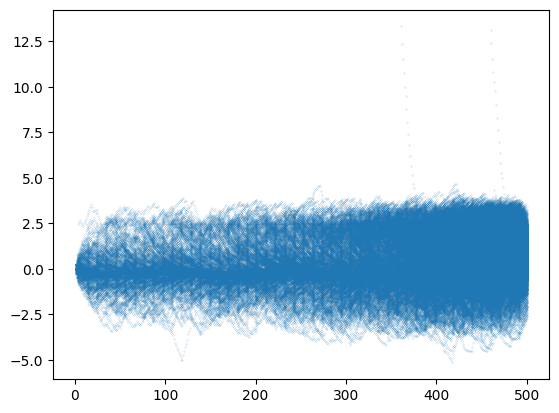

In [380]:
import matplotlib.pyplot as plt
plt.scatter(horizon[mask].cpu(),returns[mask].cpu(),s=0.01)

tensor(2.3861)

In [343]:
import torch
import torch.nn.functional as F

class BinnedKernelCritic:
    def __init__(self, n_bins=1024, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.n_bins = n_bins
        self.device = device
        self.min_val = None
        self.max_val = None
        self.bin_width = None
        
        # The learned grid (numerator and denominator)
        self.grid_val = None
        self.grid_count = None

    def fit(self, features, rtn, mask,sigma=1.0):
        """
        Discretizes data and builds the raw histograms.
        """
        # 1. Flatten and Filter
        f_flat = features[mask].float()
        r_flat = rtn[mask].float()
        
        # 2. Define Grid Range
        # Add a tiny epsilon to max to prevent index out of bounds
        self.min_val = f_flat.min()
        self.max_val = f_flat.max() + 1e-5 
        self.bin_width = (self.max_val - self.min_val) / self.n_bins
        
        # 3. Discretize Features to Bin Indices
        # shape: (N,)
        bin_indices = ((f_flat - self.min_val) / self.bin_width).long()
        bin_indices = torch.clamp(bin_indices, 0, self.n_bins - 1)
        
        # 4. Scatter Add to create Histograms
        # We need two grids: one for sum of returns, one for counts
        self.grid_rtn = torch.zeros(self.n_bins, device=self.device)
        self.grid_count = torch.zeros(self.n_bins, device=self.device)
        
        # index.add_(dim, index, src)
        self.grid_rtn.index_add_(0, bin_indices, r_flat)
        self.grid_count.index_add_(0, bin_indices, torch.ones_like(r_flat))


        # 1. Convert real-world sigma to bin-sigma
        # sigma_bins = sigma / bin_width
        sigma_bins = sigma / self.bin_width
        
        # 2. Create Gaussian Kernel
        # We need a kernel width ~ 4*sigma to capture the tails
        k_radius = int(4 * sigma_bins)
        k_size = 2 * k_radius + 1
        
        # Create kernel grid centered at 0
        k_grid = torch.arange(-k_radius, k_radius + 1, device=self.device).float()
        kernel = torch.exp(-k_grid**2 / (2 * sigma_bins**2))
        kernel = kernel / kernel.sum() # Normalize
        
        # Reshape for conv1d: (Out_C, In_C, Kernel_Len) -> (1, 1, K)
        kernel = kernel.view(1, 1, -1)
        
        # 3. Convolve Numerator and Denominator separately
        # Reshape grids to (Batch, Channel, Len) -> (1, 1, n_bins)
        g_num = self.grid_rtn.view(1, 1, -1)
        g_den = self.grid_count.view(1, 1, -1)
        
        # Padding ensures the output size remains 'n_bins'
        smooth_num = F.conv1d(g_num, kernel, padding=k_radius)
        smooth_den = F.conv1d(g_den, kernel, padding=k_radius)
        
        # 4. Compute Smoothed Value Function
        # Add epsilon to denominator to avoid division by zero in empty regions
        smooth_val = smooth_num / (smooth_den + 1e-6)
        smooth_val = smooth_val.view(-1) # Back to (n_bins,)
        self.smooth_val = smooth_val
        return torch.linspace(self.min_val.item(),self.max_val.item(),self.n_bins),smooth_val
    def predict(self, features):
        """
        Convolves the histograms and interpolates predictions.
        
        Args:
            features: Input tensor of any shape (will be flattened internally then reshaped)
            sigma: Bandwidth in FEATURE units (not bins).
        """
        original_shape = features.shape
        f_flat = features.view(-1)
        
        # 5. Interpolate for Input Features
        # We use 'grid_sample' or simple index lookup. 
        # For simplicity/speed with 1D, linear interpolation (lerp) is good.
        
        # Convert features to continuous bin coordinates
        coords = (f_flat - self.min_val) / self.bin_width
        
        # Clamp to grid range
        coords = torch.clamp(coords, 0, self.n_bins - 1.001)
        
        # Linear Interpolation manually for 1D:
        # y = y0 + (x - x0) * (y1 - y0)
        x0 = coords.long()
        x1 = x0 + 1
        alpha = coords - x0.float()
        
        y0 = self.smooth_val[x0]
        # Handle edge case where x1 is out of bounds (though clamping handled it mostly)
        y1 = self.smooth_val[torch.clamp(x1, 0, self.n_bins - 1)]
        
        preds = y0 + alpha * (y1 - y0)
        
        return preds.view(original_shape)

In [ ]:
import torch
import torch.nn.functional as F

class BinnedKernelCritic:
    def __init__(self, n_bins=1024, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.n_bins = n_bins
        self.device = device
        self.min_val = None
        self.max_val = None
        self.bin_width = None
        
        # The learned lookup table
        self.smooth_val = None

    def fit(self, features, rtn, mask, sigma=1.0, k_bandwidth=None):
        """
        Fits the critic.
        
        Args:
            sigma: Fixed bandwidth (used if k_bandwidth is None).
            k_bandwidth: If set (int), enables ADAPTIVE bandwidth.
                         The bandwidth at bin i will be the width required 
                         to capture 'k_bandwidth' samples.
        """
        # 1. Discretization Setup
        f_flat = features[mask].float()
        r_flat = rtn[mask].float()
        
        self.min_val = f_flat.min()
        self.max_val = f_flat.max() + 1e-5 
        self.bin_width = (self.max_val - self.min_val) / self.n_bins
        
        bin_indices = ((f_flat - self.min_val) / self.bin_width).long()
        bin_indices = torch.clamp(bin_indices, 0, self.n_bins - 1)
        
        # 2. Build Raw Histograms
        grid_rtn = torch.zeros(self.n_bins, device=self.device)
        grid_count = torch.zeros(self.n_bins, device=self.device)
        
        grid_rtn.index_add_(0, bin_indices, r_flat)
        grid_count.index_add_(0, bin_indices, torch.ones_like(r_flat))

        # 3. Construct Kernel Matrix
        # We create a (n_bins, n_bins) matrix where W[i, j] is weight of j on i
        i_idx = torch.arange(self.n_bins, device=self.device).float()
        
        # Distance squared matrix (B, B) using broadcasting
        # dist_sq[i, j] = (i - j)^2
        dist_sq = (i_idx.view(-1, 1) - i_idx.view(1, -1)) ** 2

        if k_bandwidth is not None:
            # --- ADAPTIVE BANDWIDTH LOGIC ---
            # 1. Compute CDF to find mass distribution
            cdf = torch.cumsum(grid_count, dim=0)
            total_count = cdf[-1]
            
            # 2. For each bin, find the range [L, R] that contains k mass
            # We use searchsorted on the CDF to do this vectorially
            k_half = k_bandwidth / 2.0
            
            # Define target mass boundaries
            target_l = (cdf - k_half).clamp(min=0)
            target_r = (cdf + k_half).clamp(max=total_count)
            
            # Find bin indices corresponding to these masses
            idx_l = torch.searchsorted(cdf, target_l)
            idx_r = torch.searchsorted(cdf, target_r)
            
            # 3. Convert bin-distance to sigma
            # Width is (right - left), sigma is roughly half width
            sigma_vec = (idx_r - idx_l).float() * 0.5
            
            # Clamp sigma to avoid division by zero or degenerate peaks
            sigma_vec = sigma_vec.clamp(min=1.0) # min 1 bin width
            
            # 4. Compute Adaptive Weights: sigma varies per ROW (i)
            # shape (B, 1) broadcasted across columns
            sigma_sq = sigma_vec.view(-1, 1) ** 2
            weights = torch.exp(-dist_sq / (2 * sigma_sq))
            
        else:
            # --- FIXED BANDWIDTH LOGIC ---
            # Standard Gaussian kernel
            sigma_bins = sigma / self.bin_width
            weights = torch.exp(-dist_sq / (2 * sigma_bins**2))

        # 4. Apply Smoothing (Matrix Multiply)
        # smooth = W @ raw
        smooth_num = weights @ grid_rtn
        smooth_den = weights @ grid_count
            
        # 5. Final Division
        self.smooth_val = smooth_num / (smooth_den + 1e-6)

        # Return x-axis and values for debugging
        x_axis = torch.linspace(self.min_val.item(), self.max_val.item(), self.n_bins, device='cpu')
        return x_axis, self.smooth_val

    def predict(self, features):
        """
        Interpolates predictions from the learned lookup table.
        """
        original_shape = features.shape
        f_flat = features.view(-1)
        
        # 1. Map to continuous bin coordinates
        coords = (f_flat - self.min_val) / self.bin_width
        coords = torch.clamp(coords, 0, self.n_bins - 1.001)
        
        # 2. Linear Interpolation
        x0 = coords.long()
        x1 = x0 + 1
        alpha = coords - x0.float()
        
        y0 = self.smooth_val[x0]
        # Safe clamp for x1 to avoid OOB
        y1 = self.smooth_val[torch.clamp(x1, 0, self.n_bins - 1)]
        
        preds = y0 + alpha * (y1 - y0)
        
        return preds.view(original_shape)

In [ ]:
import torch
import torch.nn.functional as F

class BinnedKernelCritic:
    def __init__(self, n_bins=1024, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.n_bins = n_bins
        self.device = device
        self.min_val = None
        self.max_val = None
        self.bin_width = None
        
        # The learned lookup table
        self.smooth_val = None

    def fit(self, flat_features, flat_returns, traj_ids=None, sigma=1.0, k_bandwidth=None):
        """
        Fits the critic and prepares Leave-One-Trajectory-Out (LOTO) lookup tables.
        
        Args:
            traj_ids: Tensor of same length as flat_features/flat_returns indicating trajectory membership.
                       If None, standard global fitting is done without LOTO.
            sigma: Fixed bandwidth (used if k_bandwidth is None).
            k_bandwidth: If set (int), enables ADAPTIVE bandwidth.
                         The bandwidth at bin i will be the width required 
                         to capture 'k_bandwidth' samples.
        """
        # 1. Prepare Data
        f_flat = flat_features.float().detach()
        r_flat = flat_returns.float().detach()
        if traj_ids is None:
            t_flat = torch.zeros_like(f_flat, dtype=torch.long)
        else:
            t_flat = traj_ids.long()
      
        
        # Get number of trajectories from the max ID (assuming 0-indexed contiguous)
        self.n_trajs = t_flat.max().item() + 1
        
        # 2. Discretize
        self.min_val = f_flat.min()
        self.max_val = f_flat.max() + 1e-5 
        self.bin_width = (self.max_val - self.min_val) / self.n_bins
        
        bin_indices = ((f_flat - self.min_val) / self.bin_width).long()
        bin_indices = torch.clamp(bin_indices, 0, self.n_bins - 1)
        
        # 3. Build "Global" Histograms (1D)
        # We keep these for standard predictions on new data
        global_rtn = torch.zeros(self.n_bins, device=self.device)
        global_count = torch.zeros(self.n_bins, device=self.device)
        global_rtn.index_add_(0, bin_indices, r_flat)
        global_count.index_add_(0, bin_indices, torch.ones_like(r_flat))
        
        # 4. Build "Per-Trajectory" Histograms (2D: N_trajs x N_bins)
        # Strategy: Flatten indices to 1D (traj_idx * n_bins + bin_idx) for efficient scatter
        flat_grid_idx = t_flat * self.n_bins + bin_indices
        
        traj_rtn_flat = torch.zeros(self.n_trajs * self.n_bins, device=self.device)
        traj_count_flat = torch.zeros(self.n_trajs * self.n_bins, device=self.device)
        
        traj_rtn_flat.index_add_(0, flat_grid_idx, r_flat)
        traj_count_flat.index_add_(0, flat_grid_idx, torch.ones_like(r_flat))
        
        # Reshape to matrices
        traj_rtn = traj_rtn_flat.view(self.n_trajs, self.n_bins)
        traj_count = traj_count_flat.view(self.n_trajs, self.n_bins)

        # 5. Compute Kernel Matrix (Same as before)
        i_idx = torch.arange(self.n_bins, device=self.device).float()
        dist_sq = (i_idx.view(-1, 1) - i_idx.view(1, -1)) ** 2

        if k_bandwidth is not None:
            # (Adaptive logic omitted for brevity, identical to previous snippet)
            # Just ensure 'weights' is computed here
            cdf = torch.cumsum(global_count, dim=0)
            total_count = cdf[-1]
            
            # 2. For each bin, find the range [L, R] that contains k mass
            # We use searchsorted on the CDF to do this vectorially
            k_half = k_bandwidth / 2.0
            
            # Define target mass boundaries
            target_l = (cdf - k_half).clamp(min=0)
            target_r = (cdf + k_half).clamp(max=total_count)
            
            # Find bin indices corresponding to these masses
            idx_l = torch.searchsorted(cdf, target_l)
            idx_r = torch.searchsorted(cdf, target_r)
            
            # 3. Convert bin-distance to sigma
            # Width is (right - left), sigma is roughly half width
            sigma_vec = (idx_r - idx_l).float() * 0.5
            
            # Clamp sigma to avoid division by zero or degenerate peaks
            sigma_vec = sigma_vec.clamp(min=1.0) # min 1 bin width
            
            # 4. Compute Adaptive Weights: sigma varies per ROW (i)
            # shape (B, 1) broadcasted across columns
            sigma_sq = sigma_vec.view(-1, 1) ** 2
            weights = torch.exp(-dist_sq / (2 * sigma_sq)) 
        else:
            sigma_bins = sigma / self.bin_width
            weights = torch.exp(-dist_sq / (2 * sigma_bins**2))

        # 6. Smooth Global (1 x N_bins)
        # smooth_num: (N_bins,)
        global_smooth_num = weights @ global_rtn
        global_smooth_den = weights @ global_count
        
        # 7. Smooth Trajectories (N_trajs x N_bins)
        # We multiply the stack of histograms by the weight matrix
        # (N_traj, N_bins) @ (N_bins, N_bins) -> (N_traj, N_bins)
        # Note: weights is symmetric, so order doesn't matter for Gaussian
        traj_smooth_num = traj_rtn @ weights.T
        traj_smooth_den = traj_count @ weights.T
        
        # 8. Compute "Leave-One-Out" Tables via Subtraction
        # Broadcasting: (1, N_bins) - (N_traj, N_bins)
        loo_num = global_smooth_num.unsqueeze(0) - traj_smooth_num
        loo_den = global_smooth_den.unsqueeze(0) - traj_smooth_den
        
        # Avoid division by zero and compute value
        self.loo_vals = loo_num / (loo_den + 1e-6)
        
        # Also store global vals for standard inference
        self.global_vals = global_smooth_num / (global_smooth_den + 1e-6)
        x_axis = torch.linspace(self.min_val.item(), self.max_val.item(), self.n_bins, device='cpu')
        return x_axis, self.global_vals
    
    def predict(self, features, query_traj_ids=None):
        """
        Args:
            query_traj_ids: If provided, uses the LOTO table for that specific trajectory.
                            If None, uses the global table (standard inference).
        """
        original_shape = features.shape
        f_flat = features.view(-1)
        
        # 1. Coordinate Transforms
        coords = (f_flat - self.min_val) / self.bin_width
        coords = torch.clamp(coords, 0, self.n_bins - 1.001)
        
        x0 = coords.long()
        x1 = x0 + 1
        alpha = coords - x0.float()
        x1 = torch.clamp(x1, 0, self.n_bins - 1)
        
        # 2. Select Lookup Table
        if query_traj_ids is not None:
            # CV Mode: Use LOTO table
            t_flat = query_traj_ids.view(-1)
            
            # Advanced Indexing: [traj_idx, bin_idx]
            y0 = self.loo_vals[t_flat, x0]
            y1 = self.loo_vals[t_flat, x1]
        else:
            # Standard Mode: Use Global table
            y0 = self.global_vals[x0]
            y1 = self.global_vals[x1]
        
        # 3. Interpolate
        preds = y0 + alpha * (y1 - y0)
        return preds.view(original_shape)

In [ ]:
critic_loss = []
naive_loss = []
mask = horizon<500
mask = torch.ones_like(returns,dtype=torch.bool)
feature = torch.ones_like(returns,dtype=torch.float32)*horizon.unsqueeze(-1).float()
feature = feature[mask]
returns_masked = returns[mask]
traj_ids_masked = traj_ids[mask]
sigma = 10
for i in range(5):
    indices = torch.randperm(len(feature))
    train_size = 500*500
    test_size = 500*500
    train = indices[:train_size]
    test = indices[train_size:train_size+test_size]
    temp_critic = BinnedKernelCritic(n_bins=1024,device="cpu")
    pred_indices,pred_table = temp_critic.fit(feature[train],returns_masked[train],traj_ids_masked[train],sigma=sigma)#,k_bandwidth=8000)

    pred_returns = temp_critic.predict(feature[train],traj_ids_masked[train])
    critic_loss.append(torch.nn.functional.mse_loss(pred_returns,returns_masked[train]).item())

    # print(torch.var(returns))
    naive_loss.append(torch.var(returns_masked[test]).item())
print("Critic Loss:",sum(critic_loss)/len(critic_loss))
print("Naive Loss:",sum(naive_loss)/len(naive_loss))
print("percent improvement:",(sum(naive_loss)/len(naive_loss)-sum(critic_loss)/len(critic_loss))/(sum(naive_loss)/len(naive_loss)))

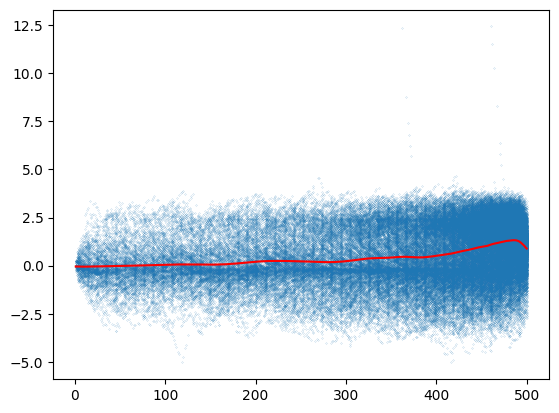

In [389]:
plt.scatter(feature[test],returns_masked[test],s=0.01)
# pred_indices = torch.linspace(temp_critic.min_val.item(),temp_critic.max_val.item(),temp_critic.n_bins)
plt.plot(pred_indices.cpu(),pred_table.cpu(),color='red')
# plt.xlim(0,10)

In [207]:
traj_batch['response_mask'].sum()

tensor(280842)

tensor(2.4725)

In [ ]:
# In a new cell at the top of your notebook:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Fixing random state for reproducibility
np.random.seed(19680801)

# Generate some random data
n = 100
xs = distance
ys = horizon
zs = returns

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot
ax.scatter(xs, ys, zs, c='b', marker='o')

# Set labels and title
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.set_title('Interactive 3D Scatter Plot')

# Display the plot
plt.show()


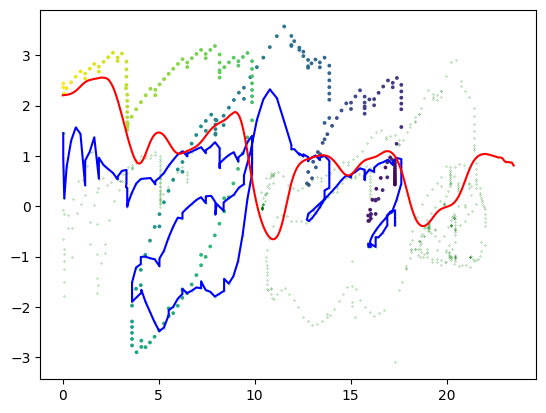

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
y = flat_rtn[traj_batch['response_mask']>0]
x = traj_batch['distance_to_goal'][traj_batch['response_mask']>0]
z = adv[traj_batch['response_mask']>0]
i = 1
traj_sample = traj_batch[i][traj_batch['response_mask'][i]>0]
traj_l = len(traj_sample)
plt.scatter(traj_sample['distance_to_goal'],traj_sample['returns'],c=np.arange(traj_l),s=3)
plt.plot(traj_sample['distance_to_goal'],traj_sample['advantage'],c='b')
# plt.scatter(x,y,s=0.04)
plt.scatter(x,z,s=0.04,c='g')
plt.plot(np.arange(len(baseline))*0.1,baseline,c='r')

In [35]:
traj_sample['advantage'][-1]

tensor(0.2795)

In [75]:
baseline[0]

tensor(2.1049)

In [76]:
a,_ = 1,

ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
baseline.shape

torch.Size([292])